In [104]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import pandas as pd
import numpy as np
import statsmodels.api as sm
from statsmodels.graphics.tsaplots import plot_acf
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

from sklearn.preprocessing import PolynomialFeatures


In [105]:
data_path = "full_dataset.csv"

# Load data

Now that we have extracted all our data and made preprocessing we are ready to start building a model. The first thing we wil do is so load the combined data and pick relevant features. As part of this we aggred to convert the topics into categorical features. By converting the hight probability value to 1. (Note : It's not actually a probability beacause we haven't normalized, but this doesn't matter)

In [106]:
########## ---------- Read data ---------- ########## 
df = pd.read_csv(data_path)
df.columns

Index(['post_date_x', 'post_count', 'n_image_only', 'avg_upvotes',
       'max_upvotes', 'total_upvotes', 'avg_reblogs', 'total_reblogs',
       'avg_replies', 'n_quotes', 'n_with_link', 'avg_text_len',
       'topic_activity_0', 'topic_activity_1', 'topic_activity_2',
       'topic_activity_3', 'topic_activity_4', 'topic_activity_5',
       'topic_activity_6', 'topic_activity_7', 'topic_activity_8',
       'topic_activity_9', 'topic_activity_10', 'topic_activity_11',
       'topic_activity_12', 'trump_sentiment_mean_x', 'trump_sentiment_std',
       'trump_sentiment_pct_negative', 'date', 'post_date_y',
       'news_sentiment_mean_y', 'news_sentiment_rolling', 'cpi',
       'interest_rate', 'consumer_sentiment', 'unemployment'],
      dtype='object')

In [107]:
# Make sure time is sorted
order = np.argsort(df["date"].values)
df = df.iloc[order]

In [108]:
########## ---------- Convert into categorical ---------- ########## 
topic_cols = [
    'topic_activity_0', 'topic_activity_1', 'topic_activity_2',
    'topic_activity_3', 'topic_activity_4', 'topic_activity_5',
    'topic_activity_6', 'topic_activity_7', 'topic_activity_8',
    'topic_activity_9', 'topic_activity_10', 'topic_activity_11'
]

# find max column per row
max_cols = df[topic_cols].idxmax(axis=1)

# zero everything
df[topic_cols] = 0

# set the max column to 1
for col in topic_cols:
    df.loc[max_cols == col, col] = 1

In [109]:
# Remove rows with no posts (these can introduce NaNs)
df = df[df["post_count"] != 0]

# Basic NaN diagnostics
nan_count = df.isna().sum().sum()
print(f"Number of NaN values: {nan_count}")

if nan_count > 0:
    failing_cols = df.columns[df.isna().any()]
    print(f"Columns with NaN: {list(failing_cols)}")

Number of NaN values: 1
Columns with NaN: ['avg_text_len']


# Pick features

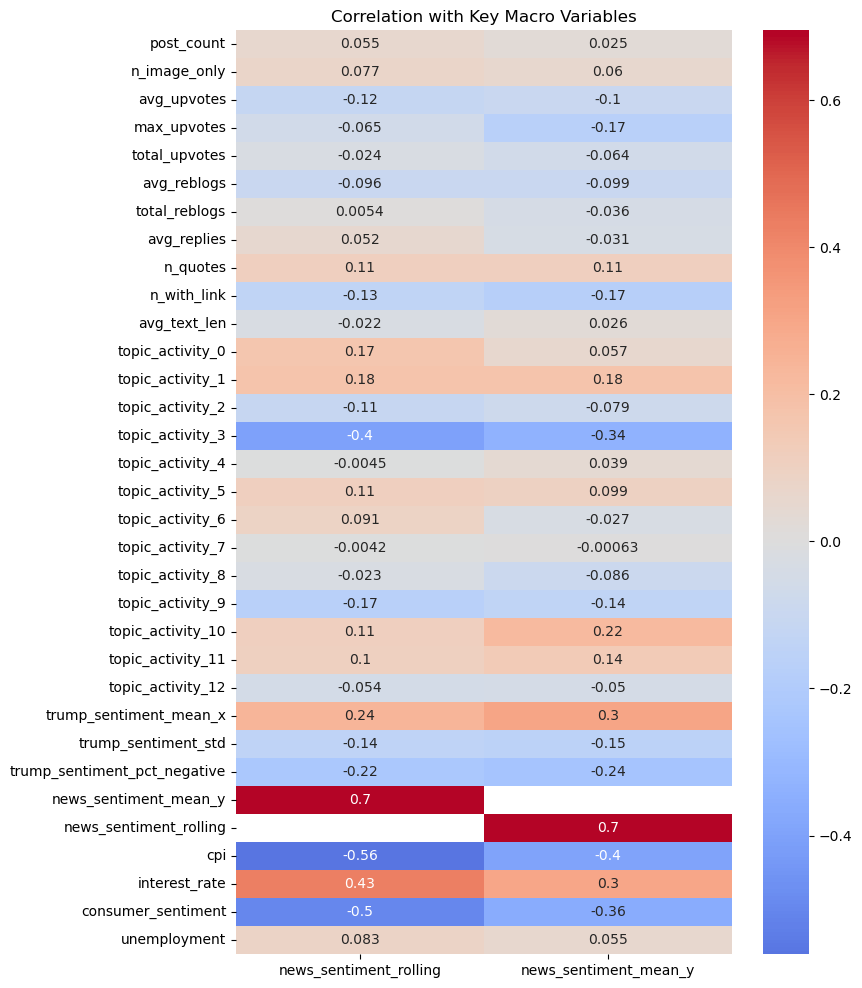

In [110]:
########## ---------- Correlation matrix ---------- ########## 
df_numeric = df.select_dtypes(include="number")
target_vars = ["news_sentiment_rolling", "news_sentiment_mean_y"]
corr_matrix = df_numeric.corr()
corr_subset = corr_matrix[target_vars]
for var in target_vars:
    corr_subset.loc[var, var] = None

plt.figure(figsize=(8, 12))
sns.heatmap(corr_subset, annot=True, cmap="coolwarm", center=0)
plt.title("Correlation with Key Macro Variables")
plt.show()

In [111]:
features = [
    'topic_activity_0', 'topic_activity_1', 'topic_activity_2',
    'topic_activity_3', 'topic_activity_4', 'topic_activity_5',
    'topic_activity_6', 'topic_activity_7', 'topic_activity_8',
    'topic_activity_9', 'topic_activity_10', 'topic_activity_11',
    'topic_activity_12', 'trump_sentiment_mean_x', 'trump_sentiment_std',
    'trump_sentiment_pct_negative', 
    'cpi', 
    'interest_rate', 
    'consumer_sentiment',
    'unemployment'
]

predictors = [
    'news_sentiment_rolling', 'news_sentiment_mean_y'
]

split_idx = int(len(df) * 0.9)

train_df = df.iloc[:split_idx].copy()
test_df  = df.iloc[split_idx:].copy()

In [112]:
print("Train range:", train_df["date"].min(), "→", train_df["date"].max())
print("Test range: ", test_df["date"].min(), "→", test_df["date"].max())

Train range: 2025-11-14 → 2026-03-26
Test range:  2026-03-27 → 2026-04-10


# Simple models

In [113]:
def train_model_ols(df, features, target, intercept_category='topic_activity_0'):
    
    # Define variables
    X = df[features].drop(columns=[intercept_category])
    y = df[target]  

    # add intercept and fit
    X = sm.add_constant(X)
    model = sm.OLS(y, X, missing='drop').fit()

    return model

def train_model_ols_second_order(df, features, target, intercept_category='topic_activity_0'):
    # Define variables
    X = df[features].drop(columns=[intercept_category], errors='ignore')
    y = df[target]

    # Add second-order terms: squares + pairwise interactions
    poly = PolynomialFeatures(
        degree=2,
        include_bias=False
    )

    X_poly = poly.fit_transform(X)
    X_poly = pd.DataFrame(
        X_poly,
        columns=poly.get_feature_names_out(X.columns),
        index=X.index
    )

    # Add intercept and fit
    X_poly = sm.add_constant(X_poly)
    model = sm.OLS(y, X_poly, missing='drop').fit()

    return model

def train_model_arx(df, features, target, y_lags=1, x_lags=1):

    base = df.copy()

    # --- Target lags ---
    y_lag_df = pd.concat(
        {
            f"{target}_lag_{lag}": base[target].shift(lag)
            for lag in range(1, y_lags + 1)
        },
        axis=1
    )

    # --- Feature lags ---
    x_lag_dict = {}

    for feature in features:
        if feature == "topic_activity_0":
            continue

        # current value
        x_lag_dict[feature] = base[feature]

        # lagged values
        for lag in range(1, x_lags + 1):
            x_lag_dict[f"{feature}_lag_{lag}"] = base[feature].shift(lag)

    x_lag_df = pd.DataFrame(x_lag_dict)

    # --- Combine everything at once ---
    X = pd.concat([y_lag_df, x_lag_df], axis=1)
    y = base[target]

    X = sm.add_constant(X)

    model = sm.OLS(y, X, missing="drop").fit()

    return model

In [114]:
def diagnose_model(model, time_data, alpha=0.05, lags=40, title=None):

    residuals = model.resid

    # --- feature stats ---
    coef = model.params.drop("const", errors="ignore")
    pvals = model.pvalues.drop("const", errors="ignore")
    significant = pvals < alpha

    # sort by absolute magnitude
    order = coef.abs().sort_values().index
    coef_sorted = coef.loc[order]
    significant_sorted = significant.loc[order]

    # --- predictions ---
    y_true = model.model.endog
    y_pred = model.fittedvalues

    # --- plotting ---
    fig, axes = plt.subplots(1, 4, figsize=(24, 5))

    # 1. ACF
    plot_acf(residuals, lags=lags, ax=axes[0])
    axes[0].set_title("ACF of Residuals")

    # 2. QQ plot
    sm.qqplot(residuals, line='s', ax=axes[1])
    axes[1].set_title("QQ Plot of Residuals")

    # 3. Feature contributions
    top_n = 15
    coef_top = coef_sorted.reindex(coef_sorted.abs().sort_values(ascending=False).head(top_n).index)
    significant_top = significant_sorted.loc[coef_top.index]

    axes[2].barh(coef_top.index, coef_top.values)

    for i, (feature, value) in enumerate(coef_top.items()):
        if significant_top.loc[feature]:
            axes[2].text(
                value,
                i,
                "  *",
                va="center",
                fontsize=12,
                fontweight="bold"
            )

    axes[2].axvline(0, linewidth=1)
    axes[2].set_title(f"Top {top_n} Feature Contributions (p < {alpha})")
    axes[2].set_xlabel("Coefficient")

    # 4. Actual vs Predicted over time
    y_true = pd.Series(model.model.endog)
    y_pred = pd.Series(model.fittedvalues)

    # force real datetimes
    time_data = pd.to_datetime(time_data, errors="coerce")

    # align lengths after OLS dropped missing rows
    valid_idx = model.model.data.row_labels
    time_data = time_data.loc[valid_idx]

    # remove any bad dates
    mask = time_data.notna()
    time_data = time_data[mask]
    y_true = y_true[mask.to_numpy()]
    y_pred = y_pred[mask.to_numpy()]

    axes[3].scatter(time_data, y_true, alpha=0.5, label="Actual")
    axes[3].plot(time_data, y_pred, linewidth=2, label="Predicted")

    axes[3].set_xlim(time_data.min(), time_data.max())

    locator = mdates.AutoDateLocator(minticks=4, maxticks=8)
    formatter = mdates.DateFormatter("%Y-%m-%d")

    axes[3].xaxis.set_major_locator(locator)
    axes[3].xaxis.set_major_formatter(formatter)

    axes[3].set_title("Actual vs Predicted (Time)")
    axes[3].set_xlabel("Date")
    axes[3].set_ylabel("Value")
    axes[3].legend()
    axes[3].tick_params(axis="x", rotation=45)

    # --- global title ---
    if title is not None:
        fig.suptitle(title, fontsize=16)

    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()

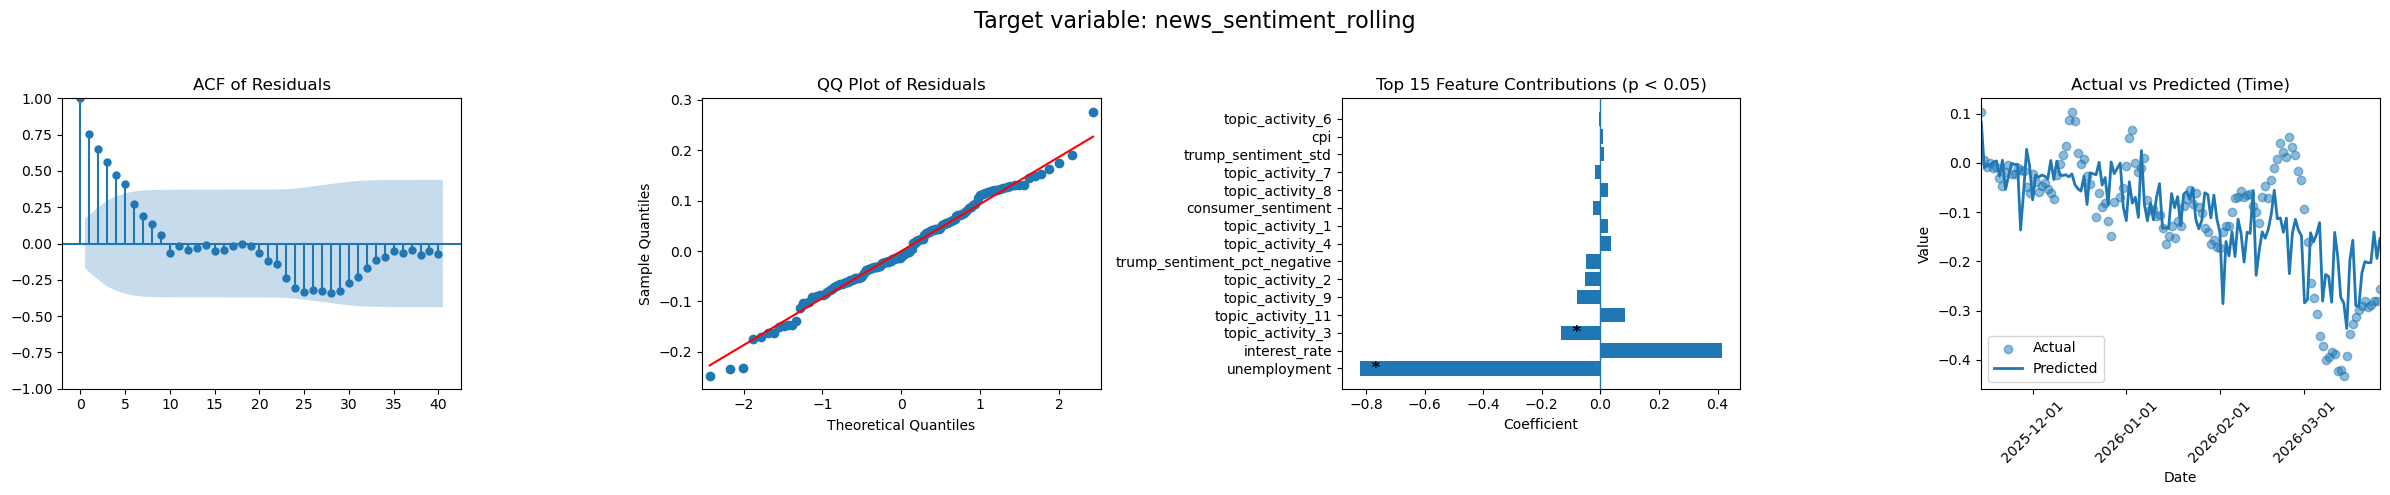

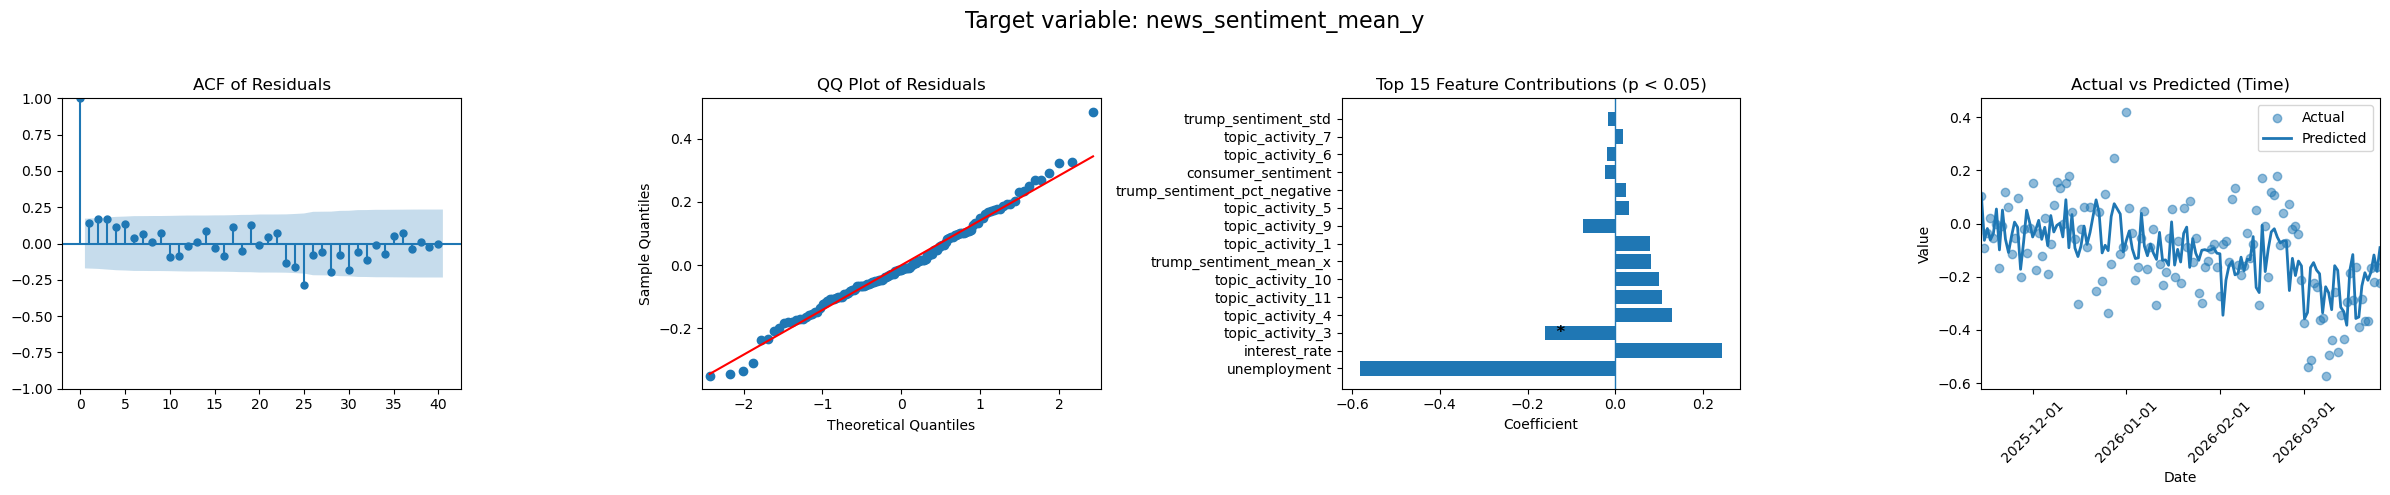

In [115]:
for i in range(len(predictors)): 
    model = train_model_ols(train_df, features, predictors[i])
    diagnose_model(model, time_data=df["date"], title=("Target variable: " + predictors[i]))

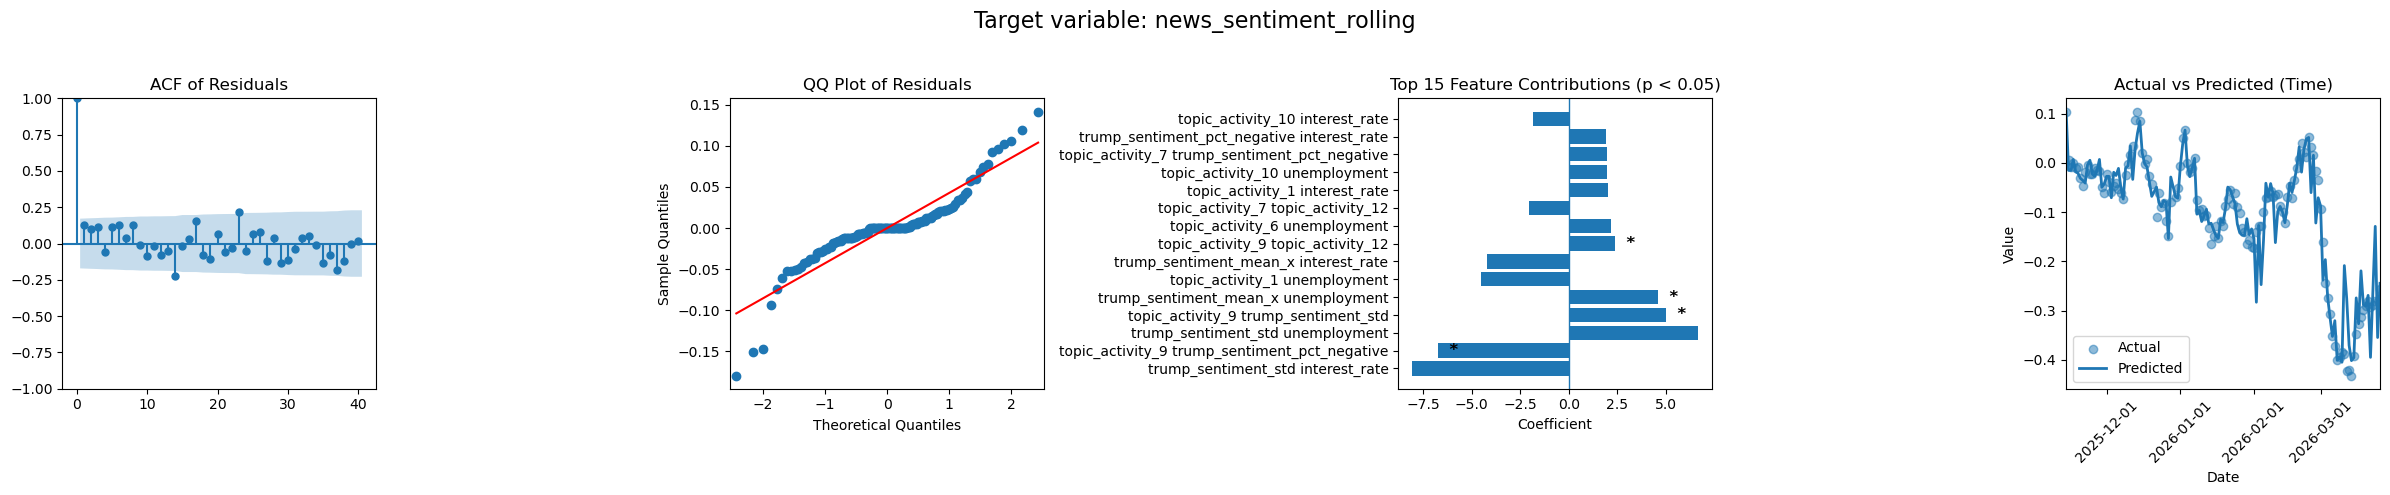

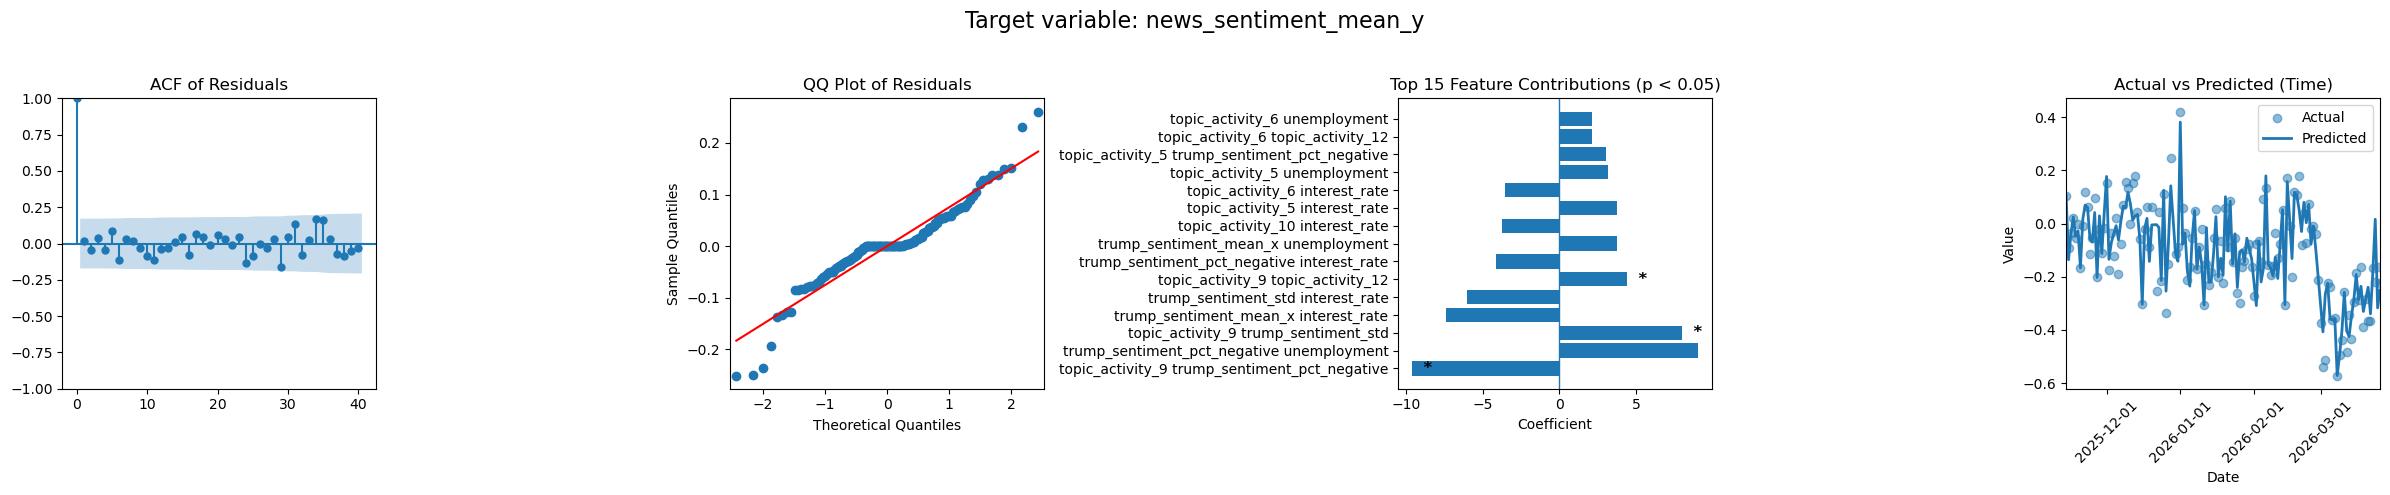

In [116]:
for i in range(len(predictors)): 
    model = train_model_ols_second_order(train_df, features, predictors[i])
    diagnose_model(model, time_data=df["date"], title=("Target variable: " + predictors[i]))

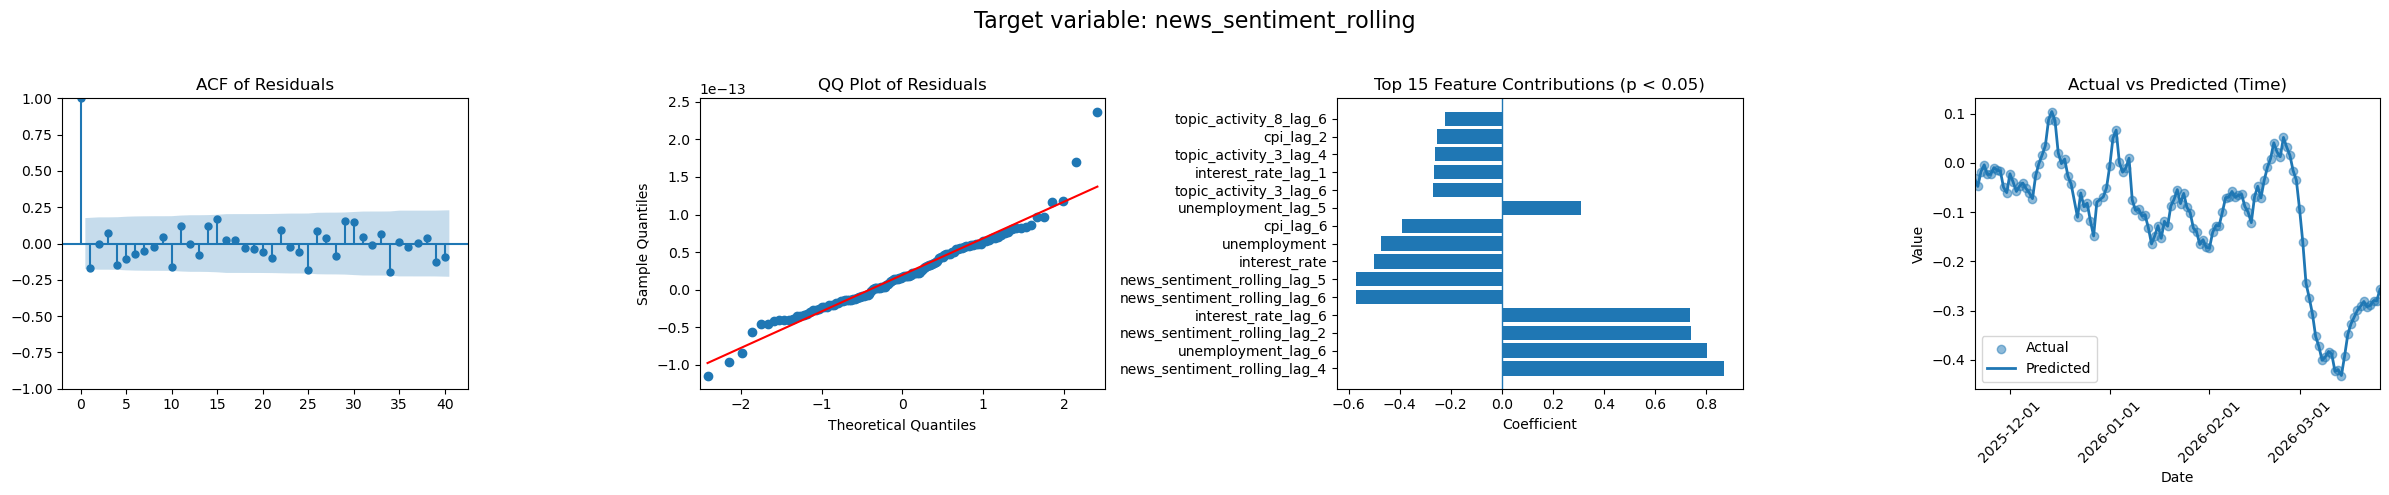

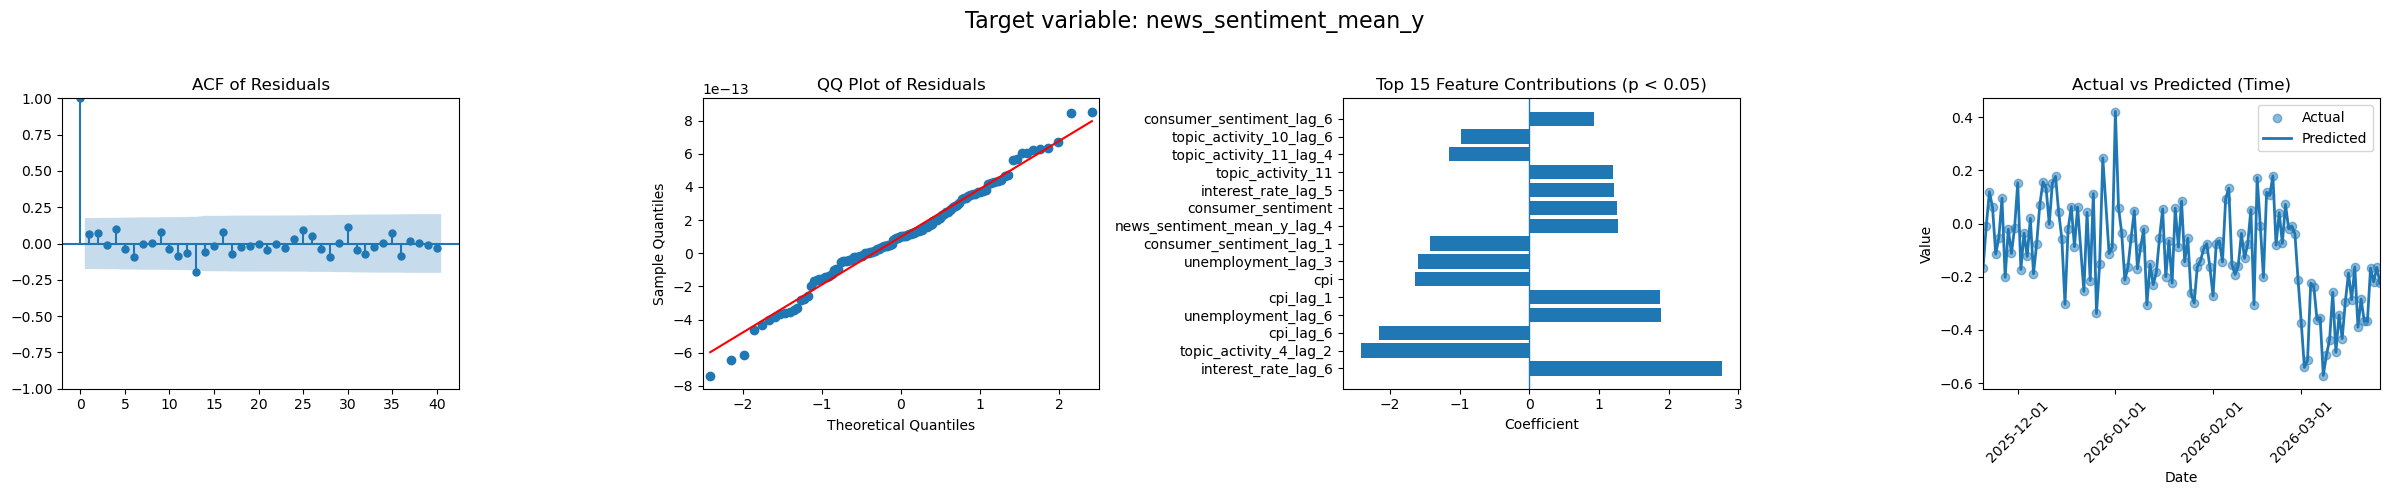

In [117]:
for i in range(len(predictors)): 
    model = train_model_arx(train_df, features, predictors[i], y_lags=6, x_lags=6)
    diagnose_model(model, time_data=df["date"], title=("Target variable: " + predictors[i]))